In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/students_raw.csv")

df.head()

,student_id,branch,cgpa,tenth_percentage,twelfth_percentage,backlogs,internships,projects,certifications,technical_skills,aptitude_score,communication_score,attendance,placed,company,package_lpa,placement_year
0,S0001,Mechanical,8.47,56.49,77.31,0,1,5,0,4,89.11,59.28,73.60,1,TCS,11.55,2026
1,S0002,Civil,6.36,80.06,89.64,0,1,1,2,4,61.98,42.25,67.15,0,Not Placed,0.00,2026
2,S0003,Electronics,7.95,97.80,89.73,4,1,3,4,4,76.09,95.07,83.40,0,Not Placed,0.00,2026
3,S0004,Civil,6.80,91.79,79.66,0,0,2,0,7,76.38,48.38,86.61,1,Capgemini,8.30,2024
4,S0005,Civil,5.46,77.42,59.51,0,1,0,5,1,61.90,73.11,88.51,0,Not Placed,0.00,2024


In [2]:
df.shape

(1250, 17)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   student_id           1250 non-null   str    
 1   branch               1250 non-null   str    
 2   cgpa                 1250 non-null   float64
 3   tenth_percentage     1250 non-null   float64
 4   twelfth_percentage   1250 non-null   float64
 5   backlogs             1250 non-null   int64  
 6   internships          1250 non-null   int64  
 7   projects             1250 non-null   int64  
 8   certifications       1250 non-null   int64  
 9   technical_skills     1250 non-null   int64  
 10  aptitude_score       1250 non-null   float64
 11  communication_score  1250 non-null   float64
 12  attendance           1250 non-null   float64
 13  placed               1250 non-null   int64  
 14  company              1250 non-null   str    
 15  package_lpa          1250 non-null   float64
 16 

In [4]:
df.describe()

,cgpa,tenth_percentage,twelfth_percentage,backlogs,internships,projects,certifications,technical_skills,aptitude_score,communication_score,attendance,placed,package_lpa,placement_year
count,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.000000,1250.0000,1250.000000,1250.000000
mean,7.539672,76.395528,72.143328,0.631200,1.052800,2.597600,1.796000,4.534400,70.794944,69.619560,79.848552,0.5000,3.694728,2025.175200
std,1.459547,12.356504,12.868421,1.060607,0.978764,1.336377,1.350201,2.326617,17.117815,17.551432,11.794696,0.5002,4.119307,0.821368
min,5.020000,55.000000,50.000000,0.000000,0.000000,0.000000,0.000000,1.000000,40.150000,40.010000,60.050000,0.0000,0.000000,2024.000000
25%,6.230000,66.152500,60.887500,0.000000,0.000000,2.000000,1.000000,2.000000,56.415000,54.240000,69.415000,0.0000,0.000000,2024.000000
50%,7.600000,76.620000,71.880000,0.000000,1.000000,3.000000,2.000000,5.000000,70.775000,68.950000,79.610000,0.5000,1.500000,2025.000000
75%,8.810000,86.767500,83.077500,1.000000,2.000000,4.000000,3.000000,7.000000,85.795000,85.395000,90.282500,1.0000,7.265000,2026.000000
max,10.000000,97.950000,94.980000,4.000000,3.000000,5.000000,5.000000,8.000000,99.980000,99.930000,99.950000,1.0000,11.980000,2026.000000


In [5]:
df["placed"].value_counts()

placed
1    625
0    625
Name: count, dtype: int64

In [6]:
df["placed"].value_counts(normalize=True) * 100

placed
1    50.0
0    50.0
Name: proportion, dtype: float64

In [7]:
df.groupby("branch")["placed"].mean() * 100

branch
Civil          56.126482
Computer       49.248120
Electronics    47.933884
IT             48.760331
Mechanical     47.773279
Name: placed, dtype: float64

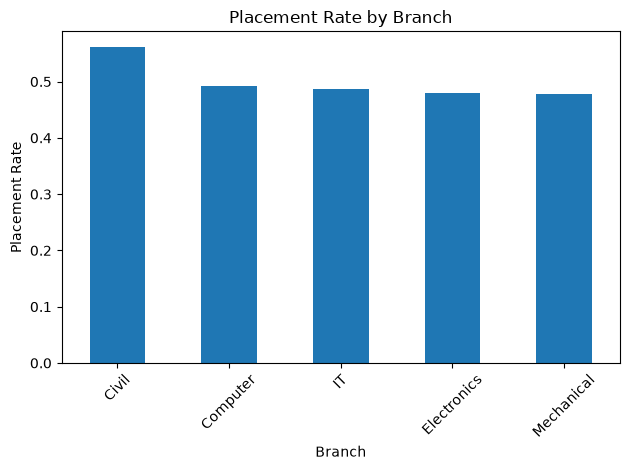

In [9]:
import matplotlib.pyplot as plt

placement_by_branch = (
    df.groupby("branch")["placed"]
    .mean()
    .sort_values(ascending=False)
)

placement_by_branch.plot(kind="bar")

plt.title("Placement Rate by Branch")
plt.xlabel("Branch")
plt.ylabel("Placement Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight:
Civil branch has the highest placement rate at approximately 56.13%.
Mechanical has the lowest placement rate at approximately 47.77%.
The placement rates of Computer, Electronics and IT are relatively close to each other.

In [10]:
df.groupby("placed")["cgpa"].mean()

placed
0    6.843344
1    8.236000
Name: cgpa, dtype: float64

In [11]:
df.groupby("backlogs")["placed"].mean() * 100

backlogs
0    54.600484
1    47.142857
2    44.230769
3    30.434783
4    19.512195
Name: placed, dtype: float64

Insight:
Placement rate decreases as the number of backlogs increases.
Students with 0 backlogs have a placement rate of approximately 54.60%,
while students with 4 backlogs have a placement rate of approximately 19.51%.
This suggests that backlogs may be an important predictive feature.

In [12]:
df.groupby("internships")["placed"].mean() * 100

internships
0    41.743119
1    49.887133
2    56.666667
3    65.648855
Name: placed, dtype: float64

## Insight – Internships vs Placement

Placement rate increases as the number of internships increases.

- 0 internships → 41.74%
- 1 internship → 49.89%
- 2 internships → 56.67%
- 3 internships → 65.65%

This suggests that internships may be an important predictive feature in the dataset.

In [13]:
df.groupby("projects")["placed"].mean() * 100

projects
0    34.722222
1    43.718593
2    46.808511
3    52.500000
4    55.909091
5    61.818182
Name: placed, dtype: float64

## Insight – Projects vs Placement

Placement rate generally increases as the number of projects increases.

- 0 projects → 34.72%
- 1 project → 43.72%
- 2 projects → 46.81%
- 3 projects → 52.50%
- 4 projects → 55.91%
- 5 projects → 61.82%

This suggests that the number of projects may be an important predictive feature in the dataset.

In [14]:
df.groupby("certifications")["placed"].mean() * 100

certifications
0    49.152542
1    51.044776
2    49.101796
3    46.666667
4    55.284553
5    52.380952
Name: placed, dtype: float64

## Insight – Certifications vs Placement

The placement rate does not show a clear increasing or decreasing pattern
with the number of certifications.

Placement rates range from approximately 46.67% to 55.28% across the
certification levels.

This suggests that the number of certifications alone may not be a strong
predictive feature in this dataset.

In [15]:
df.groupby("placed")["aptitude_score"].mean()

placed
0    68.296576
1    73.293312
Name: aptitude_score, dtype: float64

## Insight – Aptitude Score vs Placement

Placed students have a higher average aptitude score (73.29)
compared with non-placed students (68.30).

This indicates a positive relationship between aptitude score
and placement in the generated dataset.

However, aptitude score alone does not determine placement,
as multiple student features will be considered by the ML model.

In [16]:
df.groupby("placed")["communication_score"].mean()

placed
0    67.47544
1    71.76368
Name: communication_score, dtype: float64

## Insight – Communication Score vs Placement

Placed students have a higher average communication score (71.76)
compared with non-placed students (67.48).

This indicates a positive relationship between communication score
and placement in the generated dataset.

Communication score will be considered along with other features
during ML model training.

In [17]:
df.groupby("placed")["attendance"].mean()

placed
0    79.836048
1    79.861056
Name: attendance, dtype: float64

In [18]:
df.groupby("placed")["attendance"].mean()

placed
0    79.836048
1    79.861056
Name: attendance, dtype: float64

In [19]:
df.groupby("placed")["tenth_percentage"].mean()

placed
0    75.472992
1    77.318064
Name: tenth_percentage, dtype: float64

In [20]:
df.groupby("placed")["twelfth_percentage"].mean()

placed
0    70.581344
1    73.705312
Name: twelfth_percentage, dtype: float64

In [21]:
df.groupby("technical_skills")["placed"].mean() * 100

technical_skills
1    38.787879
2    34.615385
3    49.230769
4    47.953216
5    51.034483
6    49.677419
7    69.753086
8    58.433735
Name: placed, dtype: float64

In [22]:
df.groupby("placement_year")["placed"].mean() * 100

placement_year
2024    53.172205
2025    46.070461
2026    50.727273
Name: placed, dtype: float64

In [23]:
numeric_columns = [
    "cgpa",
    "tenth_percentage",
    "twelfth_percentage",
    "backlogs",
    "internships",
    "projects",
    "certifications",
    "technical_skills",
    "aptitude_score",
    "communication_score",
    "attendance",
    "placed"
]

df[numeric_columns].corr()["placed"].sort_values(ascending=False)

placed                 1.000000
cgpa                   0.477276
technical_skills       0.176808
internships            0.152089
aptitude_score         0.146010
projects               0.128758
communication_score    0.122211
twelfth_percentage     0.121430
tenth_percentage       0.074690
certifications         0.012448
attendance             0.001061
backlogs              -0.163745
Name: placed, dtype: float64

## Insight – Attendance vs Placement

The average attendance is almost identical for placed and non-placed students
(79.86% vs 79.84%).

This indicates that attendance has very little relationship with placement
in the generated dataset.

## Insight – 10th Percentage vs Placement

Placed students have a slightly higher average 10th percentage (77.32%)
than non-placed students (75.47%).

This indicates a weak positive relationship with placement in the dataset.

## Insight – 12th Percentage vs Placement

Placed students have a higher average 12th percentage (73.71%)
than non-placed students (70.58%).

This indicates a positive relationship between 12th percentage
and placement in the generated dataset.

## Insight – Technical Skills vs Placement

Placement rate generally tends to be higher for students with more technical
skills, although the relationship is not perfectly increasing.

Students with 7 technical skills have the highest placement rate at 69.75%.

This suggests that technical skills may be an important predictive feature.

## Insight – Placement Rate by Year

The placement rate was 53.17% in 2024, decreased to 46.07% in 2025,
and increased to 50.73% in 2026.

The generated dataset does not show a consistent year-over-year trend.

# Overall EDA Findings

The exploratory data analysis revealed the following patterns:

1. CGPA shows the strongest positive relationship with placement.
2. Technical skills, internships, aptitude score, projects and communication
   score also show positive relationships with placement.
3. Backlogs show a negative relationship with placement.
4. 12th percentage has a slightly stronger relationship with placement
   than 10th percentage.
5. Certifications and attendance show very weak relationships with placement.
6. Placement rates vary across branches, with Civil showing the highest rate
   in this generated dataset.
7. Placement rates vary across years without a consistent year-over-year trend.

These findings will help guide feature selection and model development.